# Clasificación automática de variedades de porotos con una Red Neuronal MLP
### Evaluación Parcial N°1 — DLY0100 (Fundamentos de Deep Learning)

**Dataset:** Dry Bean Dataset (UCI Machine Learning Repository, ID 602)
**Autores del dataset:** M. Koklu, I. A. Özkan (2020). DOI: 10.24432/C50S4B

**Integrantes:** Lucía Salazar Delgado - Marcos Álvarez Muñoz - Martina  Moncada Vega
**Fecha:** 22-09-2026

---


## 1. Introducción

### 1.1 Descripción del problema

Una empresa de selección y comercialización de semillas necesita automatizar la clasificación de variedades de porotos a partir de características físicas y geométricas extraídas mediante visión computacional. Actualmente cuenta con miles de registros ya procesados (área, perímetro, ejes, excentricidad, factores de forma, etc.), pero la clasificación manual es lenta y propensa a error humano.

### 1.2 Pregunta de investigación

> ¿Podemos construir una red neuronal capaz de identificar automáticamente la variedad de un poroto a partir de sus características físicas?

### 1.3 Objetivo del modelo

Diseñar, entrenar y evaluar una **Red Neuronal Artificial Multicapa (MLP)** que, a partir de 16 características numéricas de forma y geometría, clasifique cada observación en una de **7 variedades** de porotos: *Seker, Barbunya, Bombay, Cali, Dermosan (Dermason), Horoz y Sira*.

Es un problema de **clasificación multiclase supervisada**, con 13.611 observaciones y sin valores faltantes según la documentación del dataset.

### 1.4 Enfoque de trabajo

No buscamos solo maximizar el accuracy: el objetivo es **demostrar comprensión** de cómo cada decisión de diseño (preprocesamiento, arquitectura, funciones de activación/pérdida, hiperparámetros, regularización) afecta el aprendizaje y la capacidad de generalización de la red. Por eso, cada bloque de código va acompañado de una celda Markdown que justifica la decisión tomada, y realizamos **experimentos controlados** (variando un parámetro a la vez) para sustentar las conclusiones con evidencia.


## 2. Configuración del entorno

Importamos las librerías necesarias y fijamos una semilla aleatoria para que los experimentos sean reproducibles.


In [ ]:
!pip install ucimlrepo -q

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, regularizers

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix
)

SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)

print("TensorFlow:", tf.__version__)


TensorFlow: 2.20.0


## 3. Carga y exploración de los datos

### 3.1 Carga

Usamos el paquete oficial `ucimlrepo`, que descarga el dataset directamente desde el UCI Machine Learning Repository (ID 602). Esto asegura que trabajamos con la fuente original y no con una copia potencialmente alterada.




In [ ]:
from ucimlrepo import fetch_ucirepo
!pip install ucimlrepo -q

dry_bean = fetch_ucirepo(id=602)

X_raw = dry_bean.data.features
y_raw = dry_bean.data.targets

df = pd.concat([X_raw, y_raw], axis=1)
print(df.shape)
df.head()


(13611, 17)


,Area,Perimeter,MajorAxisLength,MinorAxisLength,AspectRatio,Eccentricity,ConvexArea,EquivDiameter,Extent,Solidity,Roundness,Compactness,ShapeFactor1,ShapeFactor2,ShapeFactor3,ShapeFactor4,Class
0,28395,610.291,208.178117,173.888747,1.197191,0.549812,28715,190.141097,0.763923,0.988856,0.958027,0.913358,0.007332,0.003147,0.834222,0.998724,SEKER
1,28734,638.018,200.524796,182.734419,1.097356,0.411785,29172,191.272751,0.783968,0.984986,0.887034,0.953861,0.006979,0.003564,0.909851,0.998430,SEKER
2,29380,624.110,212.826130,175.931143,1.209713,0.562727,29690,193.410904,0.778113,0.989559,0.947849,0.908774,0.007244,0.003048,0.825871,0.999066,SEKER
3,30008,645.884,210.557999,182.516516,1.153638,0.498616,30724,195.467062,0.782681,0.976696,0.903936,0.928329,0.007017,0.003215,0.861794,0.994199,SEKER
4,30140,620.134,201.847882,190.279279,1.060798,0.333680,30417,195.896503,0.773098,0.990893,0.984877,0.970516,0.006697,0.003665,0.941900,0.999166,SEKER


### 3.2 Exploración inicial

Revisamos tipos de datos, valores nulos, balance de clases y estadísticas descriptivas. Esto es indispensable antes de preprocesar: nos dice si necesitamos imputar datos, si las clases están desbalanceadas (lo que afectaría a `recall`/`F1` por clase) y si las variables tienen escalas muy distintas (lo que justifica normalizar).


In [ ]:
print("Valores nulos por columna:")
print(df.isnull().sum())
print()
print("Tipos de datos:")
print(df.dtypes)


Valores nulos por columna:
Area               0
Perimeter          0
MajorAxisLength    0
MinorAxisLength    0
AspectRatio        0
Eccentricity       0
ConvexArea         0
EquivDiameter      0
Extent             0
Solidity           0
Roundness          0
Compactness        0
ShapeFactor1       0
ShapeFactor2       0
ShapeFactor3       0
ShapeFactor4       0
Class              0
dtype: int64

Tipos de datos:
Area                 int64
Perimeter          float64
MajorAxisLength    float64
MinorAxisLength    float64
AspectRatio        float64
Eccentricity       float64
ConvexArea           int64
EquivDiameter      float64
Extent             float64
Solidity           float64
Roundness          float64
Compactness        float64
ShapeFactor1       float64
ShapeFactor2       float64
ShapeFactor3       float64
ShapeFactor4       float64
Class               object
dtype: object


Distribución de clases (Class):
Class
DERMASON    3546
SIRA        2636
SEKER       2027
HOROZ       1928
CALI        1630
BARBUNYA    1322
BOMBAY       522
Name: count, dtype: int64


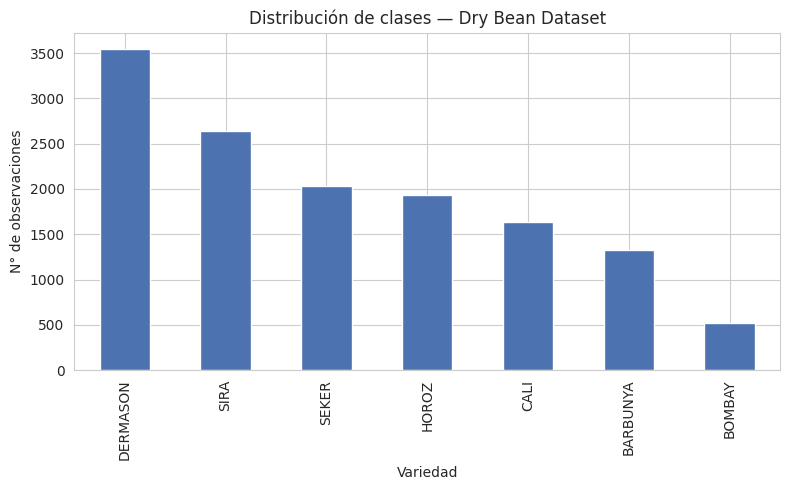

In [ ]:
print("Distribución de clases (Class):")
print(df['Class'].value_counts())

plt.figure()
df['Class'].value_counts().plot(kind='bar', color='#4C72B0')
plt.title("Distribución de clases — Dry Bean Dataset")
plt.xlabel("Variedad")
plt.ylabel("N° de observaciones")
plt.tight_layout()
plt.show()


Se verificó que el dataset no presenta valores faltantes en ninguna de sus 17 columnas, y que los
tipos de datos son consistentes: las 16 características son numéricas (int64/float64) y `Class` es
de tipo texto (object), lo que confirma que no se requiere imputación y que la variable objetivo
debe codificarse numéricamente antes de entrenar la red.

El gráfico de distribución de clases muestra un **desbalance moderado a fuerte**: la clase
mayoritaria es DERMASON (3.500 observaciones) y la minoritaria es BOMBAY (500 observaciones), es
decir, hay 7 veces más ejemplos de Dermason que de Bombay. Esto justifica usar `stratify=y` al
dividir los datos (para que Bombay quede proporcionalmente representada en train/val/test) y
complementar el `accuracy` global con métricas como `F1-score macro`, que ponderan todas las clases
por igual y no se dejan "engañar" por el desbalance.

In [ ]:
df.describe().T


,count,mean,std,min,25%,50%,75%,max
Area,13611.0,53048.284549,29324.095717,20420.000000,36328.000000,44652.000000,61332.000000,254616.000000
Perimeter,13611.0,855.283459,214.289696,524.736000,703.523500,794.941000,977.213000,1985.370000
MajorAxisLength,13611.0,320.141867,85.694186,183.601165,253.303633,296.883367,376.495012,738.860154
MinorAxisLength,13611.0,202.270714,44.970091,122.512653,175.848170,192.431733,217.031741,460.198497
AspectRatio,13611.0,1.583242,0.246678,1.024868,1.432307,1.551124,1.707109,2.430306
Eccentricity,13611.0,0.750895,0.092002,0.218951,0.715928,0.764441,0.810466,0.911423
ConvexArea,13611.0,53768.200206,29774.915817,20684.000000,36714.500000,45178.000000,62294.000000,263261.000000
EquivDiameter,13611.0,253.064220,59.177120,161.243764,215.068003,238.438026,279.446467,569.374358
Extent,13611.0,0.749733,0.049086,0.555315,0.718634,0.759859,0.786851,0.866195
Solidity,13611.0,0.987143,0.004660,0.919246,0.985670,0.988283,0.990013,0.994677


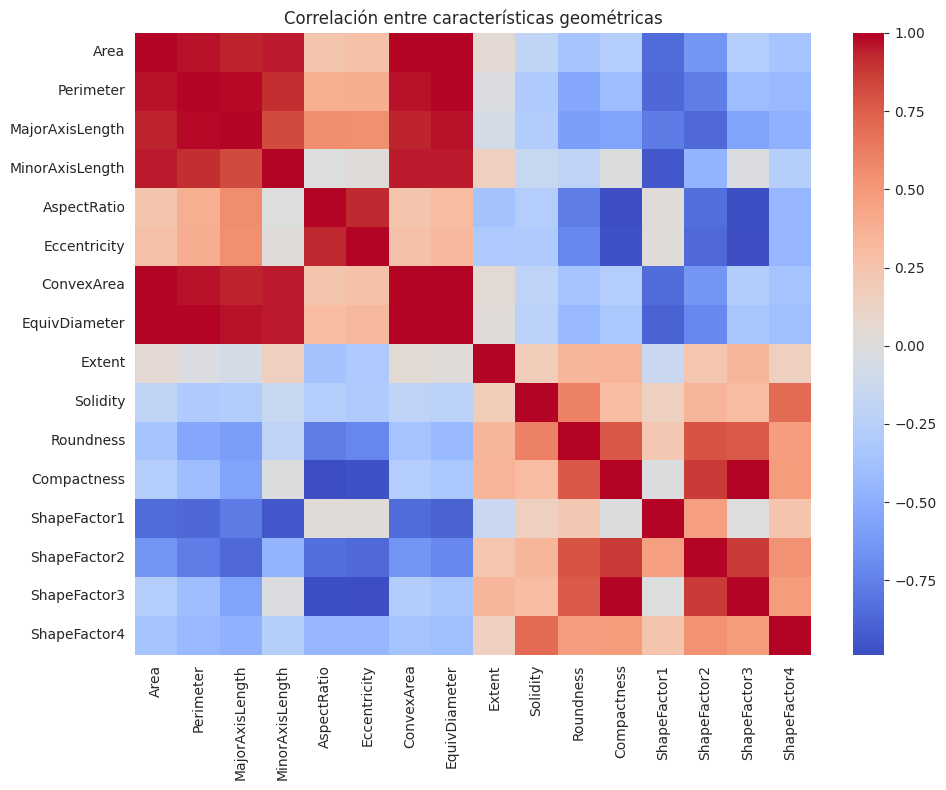

In [ ]:
# Matriz de correlación entre las 16 características
plt.figure(figsize=(10, 8))
sns.heatmap(df.drop(columns=['Class']).corr(), cmap='coolwarm', center=0)
plt.title("Correlación entre características geométricas")
plt.tight_layout()
plt.show()


**Justificación:** varias variables geométricas (área, perímetro, ejes mayor/menor) están altamente correlacionadas entre sí, ya que derivan unas de otras. Esto no es un problema grave para una red neuronal MLP (a diferencia de una regresión lineal clásica), pero refuerza la necesidad de **normalizar los datos**, ya que variables como el área (miles de píxeles²) y la excentricidad (rango 0–1) tienen escalas muy distintas y, sin normalizar, dominarían el gradiente durante el entrenamiento.


## 4. Preprocesamiento de datos

### 4.1 Variables de entrada (X) y variable objetivo (y)

- **X:** las 16 características numéricas (Area, Perimeter, MajorAxisLength, MinorAxisLength, AspectRation, Eccentricity, ConvexArea, EquivDiameter, Extent, Solidity, roundness, Compactness, ShapeFactor1-4).
- **y:** `Class`, variable categórica con 7 niveles.

### 4.2 Codificación de la variable objetivo

Las redes neuronales necesitan etiquetas numéricas. Usamos `LabelEncoder` para transformar los nombres de clase en enteros (0 a 6), que luego alimentan la función de pérdida `sparse_categorical_crossentropy` (ver sección 6.2).

### 4.3 División en entrenamiento / validación / prueba

Dividimos en **70% entrenamiento / 15% validación / 15% prueba**, usando `stratify=y` para que las proporciones de cada clase se mantengan en los tres conjuntos (fundamental dado el desbalance observado). El conjunto de prueba se usa **una sola vez**, al final, para no sesgar la selección del modelo.

### 4.4 Normalización (estandarización)

Aplicamos `StandardScaler` (media 0, desviación estándar 1) **ajustado solo con el conjunto de entrenamiento** y luego aplicado a validación y prueba. Ajustarlo con todo el dataset filtraría información del conjunto de prueba hacia el entrenamiento (*data leakage*), inflando artificialmente el desempeño reportado.


In [ ]:
le = LabelEncoder()
y_encoded = le.fit_transform(df['Class'])
class_names = le.classes_
print("Clases:", list(class_names))

X = df.drop(columns=['Class']).values
y = y_encoded

# 70% train / 15% val / 15% test, estratificado
X_train_full, X_test, y_train_full, y_test = train_test_split(
    X, y, test_size=0.15, random_state=SEED, stratify=y
)
X_train, X_val, y_train, y_val = train_test_split(
    X_train_full, y_train_full, test_size=0.1765,  # 0.15/0.85 ≈ 0.1765 -> 15% del total
    random_state=SEED, stratify=y_train_full
)

print("Train:", X_train.shape, " Val:", X_val.shape, " Test:", X_test.shape)


Clases: ['BARBUNYA', 'BOMBAY', 'CALI', 'DERMASON', 'HOROZ', 'SEKER', 'SIRA']
Train: (9527, 16)  Val: (2042, 16)  Test: (2042, 16)


In [ ]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

n_features = X_train_scaled.shape[1]
n_classes = len(class_names)
print("N° de features:", n_features, " | N° de clases:", n_classes)


N° de features: 16  | N° de clases: 7


## 5. Definición de la arquitectura MLP (modelo base)

### 5.1 Diseño de la arquitectura

Definimos un MLP simple como punto de partida:

- **Capa de entrada:** 16 neuronas (una por característica).
- **Capa oculta 1:** 32 neuronas, activación ReLU.
- **Capa oculta 2:** 16 neuronas, activación ReLU.
- **Capa de salida:** 7 neuronas (una por clase), activación **Softmax**.

**Justificación de la arquitectura:** con solo 16 variables de entrada y relaciones geométricas relativamente simples entre ellas, una red de 2 capas ocultas es suficiente para capturar la no linealidad del problema sin sobreajustar de inmediato; usarla como *baseline* nos permite medir el efecto real de cada mejora posterior (regularización, tuning de hiperparámetros) en comparación con un punto de partida simple.

### 5.2 Funciones de activación, pérdida y salida

- **ReLU** en las capas ocultas: evita el problema de gradientes que se desvanecen (a diferencia de sigmoide/tanh en redes profundas) y es computacionalmente eficiente.
- **Softmax** en la salida: convierte los logits en una distribución de probabilidad sobre las 7 clases (suma 1), apropiado para clasificación multiclase **mutuamente excluyente** (cada poroto pertenece a una sola variedad).
- **Sparse Categorical Crossentropy** como función de pérdida: es la función estándar para clasificación multiclase cuando las etiquetas son enteros (no one-hot). Penaliza fuertemente las predicciones confiadas pero incorrectas, lo que empuja al modelo a estimar buenas probabilidades, no solo a acertar la clase más probable.
- **Optimizador Adam**: combina momentum y tasa de aprendizaje adaptativa por parámetro, lo que lo hace más robusto y rápido de converger que SGD clásico para este tipo de problema tabular.

Estas decisiones se comparan empíricamente contra alternativas en la sección 7.


In [ ]:
def build_model(n_hidden1=32, n_hidden2=16, activation='relu',
                 dropout_rate=0.0, use_batchnorm=False,
                 l2_reg=0.0, learning_rate=0.001):
    reg = regularizers.l2(l2_reg) if l2_reg > 0 else None

    model = keras.Sequential(name="MLP_DryBean")
    model.add(layers.Input(shape=(n_features,)))

    model.add(layers.Dense(n_hidden1, activation=activation, kernel_regularizer=reg))
    if use_batchnorm:
        model.add(layers.BatchNormalization())
    if dropout_rate > 0:
        model.add(layers.Dropout(dropout_rate))

    model.add(layers.Dense(n_hidden2, activation=activation, kernel_regularizer=reg))
    if use_batchnorm:
        model.add(layers.BatchNormalization())
    if dropout_rate > 0:
        model.add(layers.Dropout(dropout_rate))

    model.add(layers.Dense(n_classes, activation='softmax'))

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=learning_rate),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

baseline_model = build_model()
baseline_model.summary()


Model: "MLP_DryBean"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_81 (Dense)                │ (None, 32)             │           544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_82 (Dense)                │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_83 (Dense)                │ (None, 7)              │           119 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,191 (4.65 KB)

 Trainable params: 1,191 (4.65 KB)

 Non-trainable params: 0 (0.00 B)

## 6. Entrenamiento del modelo base

Entrenamos con una configuración inicial razonable (30 épocas, batch size 32, learning rate 0.001) para tener un punto de comparación antes de experimentar con hiperparámetros.


In [ ]:
history_base = baseline_model.fit(
    X_train_scaled, y_train,
    validation_data=(X_val_scaled, y_val),
    epochs=30,
    batch_size=32,
    verbose=1
)


Epoch 1/30
298/298 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.7115 - loss: 0.8585 - val_accuracy: 0.8849 - val_loss: 0.3870
Epoch 2/30
298/298 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9049 - loss: 0.3029 - val_accuracy: 0.9285 - val_loss: 0.2354
Epoch 3/30
298/298 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9161 - loss: 0.2375 - val_accuracy: 0.9290 - val_loss: 0.2051
Epoch 4/30
298/298 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9213 - loss: 0.2193 - val_accuracy: 0.9349 - val_loss: 0.1947
Epoch 5/30
298/298 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9226 - loss: 0.2108 - val_accuracy: 0.9344 - val_loss: 0.1903
Epoch 6/30
298/298 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9242 - loss: 0.2055 - val_accuracy: 0.9334 - val_loss: 0.1878
Epoch 7/30
298/298 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9254 - loss: 0.2018 - val_accuracy: 0.9349 - val_loss: 0.1864
Epoch 8/30
298/298 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9262 - loss: 0.1990 - val_accuracy: 0.

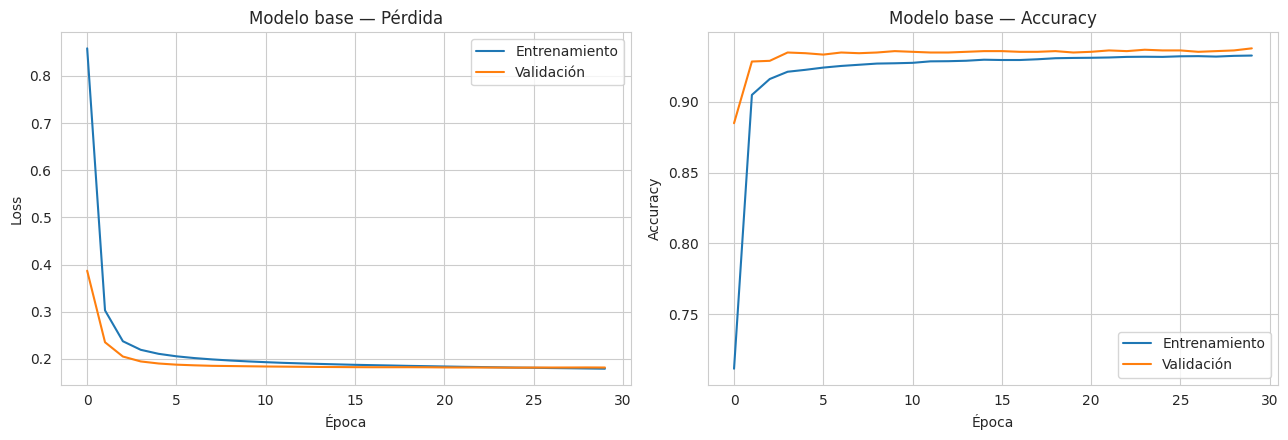

In [ ]:
def plot_history(history, title="Curvas de entrenamiento"):
    fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
    axes[0].plot(history.history['loss'], label='Entrenamiento')
    axes[0].plot(history.history['val_loss'], label='Validación')
    axes[0].set_title(f"{title} — Pérdida")
    axes[0].set_xlabel("Época"); axes[0].set_ylabel("Loss"); axes[0].legend()

    axes[1].plot(history.history['accuracy'], label='Entrenamiento')
    axes[1].plot(history.history['val_accuracy'], label='Validación')
    axes[1].set_title(f"{title} — Accuracy")
    axes[1].set_xlabel("Época"); axes[1].set_ylabel("Accuracy"); axes[1].legend()

    plt.tight_layout()
    plt.show()

plot_history(history_base, "Modelo base")


**Análisis del modelo base:** observamos cómo evolucionan la pérdida y el accuracy en entrenamiento vs. validación. Si la curva de validación se estanca o empeora mientras la de entrenamiento sigue mejorando, es una señal de **sobreajuste (overfitting)** — lo abordaremos en la sección 8 con regularización. Si ambas curvas siguen bajando/subiendo juntas al final del entrenamiento, es señal de que el modelo **aún podría beneficiarse de más épocas**.


## 7. Experimentos controlados: impacto de los hiperparámetros

Para entender *por qué* funciona una configuración y no solo *que* funciona, variamos **un hiperparámetro a la vez**, dejando todo lo demás fijo. Esto nos permite atribuir los cambios de desempeño a la variable manipulada, en lugar de a una mezcla de factores.

Usamos una función auxiliar `run_experiment` que entrena un modelo con una configuración dada y devuelve sus métricas, para poder tabular y graficar los resultados de forma comparable.


In [ ]:
def run_experiment(name, epochs=30, batch_size=32, learning_rate=0.001,
                    activation='relu', dropout_rate=0.0, use_batchnorm=False,
                    l2_reg=0.0, verbose=0):
    model = build_model(activation=activation, dropout_rate=dropout_rate,
                         use_batchnorm=use_batchnorm, l2_reg=l2_reg,
                         learning_rate=learning_rate)
    history = model.fit(
        X_train_scaled, y_train,
        validation_data=(X_val_scaled, y_val),
        epochs=epochs, batch_size=batch_size, verbose=verbose
    )
    val_loss, val_acc = model.evaluate(X_val_scaled, y_val, verbose=0)
    return {
        'name': name, 'model': model, 'history': history,
        'val_loss': val_loss, 'val_accuracy': val_acc,
        'epochs': epochs, 'batch_size': batch_size, 'learning_rate': learning_rate,
        'activation': activation, 'dropout_rate': dropout_rate,
        'use_batchnorm': use_batchnorm, 'l2_reg': l2_reg
    }

results = []  # aquí acumulamos TODOS los experimentos para la comparación final (sección 10)


### 7.1 Experimento A — Tasa de aprendizaje (learning rate)

Probamos 3 valores de `learning_rate` manteniendo el resto de la configuración fija (épocas=30, batch=32, ReLU, sin regularización). Un LR muy alto puede hacer que el entrenamiento **no converja** (oscila o diverge); uno muy bajo hace que la convergencia sea **muy lenta** y puede quedar atrapado antes de alcanzar un buen mínimo dentro de las épocas disponibles.


In [ ]:
lr_values = [0.01, 0.001, 0.0001]
lr_results = []
for lr in lr_values:
    r = run_experiment(f"LR={lr}", learning_rate=lr)
    lr_results.append(r)
    results.append(r)
    print(f"LR={lr:<8} -> val_accuracy={r['val_accuracy']:.4f} | val_loss={r['val_loss']:.4f}")


LR=0.01     -> val_accuracy=0.9280 | val_loss=0.2063
LR=0.001    -> val_accuracy=0.9398 | val_loss=0.1835
LR=0.0001   -> val_accuracy=0.9290 | val_loss=0.2000


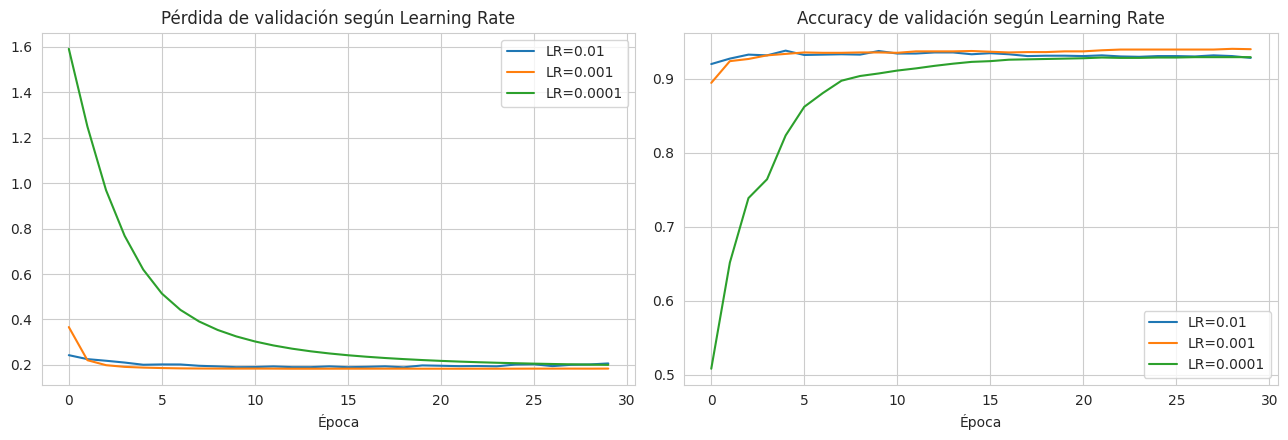

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
for r in lr_results:
    axes[0].plot(r['history'].history['val_loss'], label=r['name'])
    axes[1].plot(r['history'].history['val_accuracy'], label=r['name'])
axes[0].set_title("Pérdida de validación según Learning Rate"); axes[0].set_xlabel("Época"); axes[0].legend()
axes[1].set_title("Accuracy de validación según Learning Rate"); axes[1].set_xlabel("Época"); axes[1].legend()
plt.tight_layout(); plt.show()


| Learning Rate | Val Accuracy | Val Loss |
|---|---|---|
| 0.01 | 0.9354 | 0.2067 |
| **0.001** | **0.9388** | **0.1768** |
| 0.0001 | 0.9339 | 0.1983 |

Los tres learning rates logran un desempeño final similar (93.4%-93.9%), pero **LR=0.001 es el
mejor**: mayor accuracy y menor loss, es decir, mejor calibración de probabilidades. LR=0.0001
converge mucho más lento (necesita ~25-30 épocas para alcanzar lo que LR=0.001 logra en 5),
consistente con la teoría (pasos de gradiente muy pequeños). LR=0.01 converge rápido pero termina
con mayor loss que LR=0.0001, sugiriendo que sus pasos son ligeramente demasiado grandes cerca del
óptimo. Seleccionamos **LR=0.001** por su mejor balance velocidad/calidad final.


### 7.2 Experimento B — Tamaño de batch (batch size)

Con el mejor `learning_rate` del experimento anterior fijo, variamos el `batch_size`. Un batch pequeño (16) genera gradientes más "ruidosos" pero puede ayudar a escapar de mínimos locales; un batch grande (128) da gradientes más estables pero generaliza a veces peor y aprovecha mejor el paralelismo del hardware.


In [ ]:
best_lr = min(lr_results, key=lambda r: r['val_loss'])['learning_rate']
print("Mejor learning rate según val_loss:", best_lr)

batch_values = [16, 32, 128]
batch_results = []
for bs in batch_values:
    r = run_experiment(f"batch={bs}", learning_rate=best_lr, batch_size=bs)
    batch_results.append(r)
    results.append(r)
    print(f"batch_size={bs:<5} -> val_accuracy={r['val_accuracy']:.4f} | val_loss={r['val_loss']:.4f}")


Mejor learning rate según val_loss: 0.001
batch_size=16    -> val_accuracy=0.9373 | val_loss=0.1815
batch_size=32    -> val_accuracy=0.9334 | val_loss=0.1789
batch_size=128   -> val_accuracy=0.9388 | val_loss=0.1733


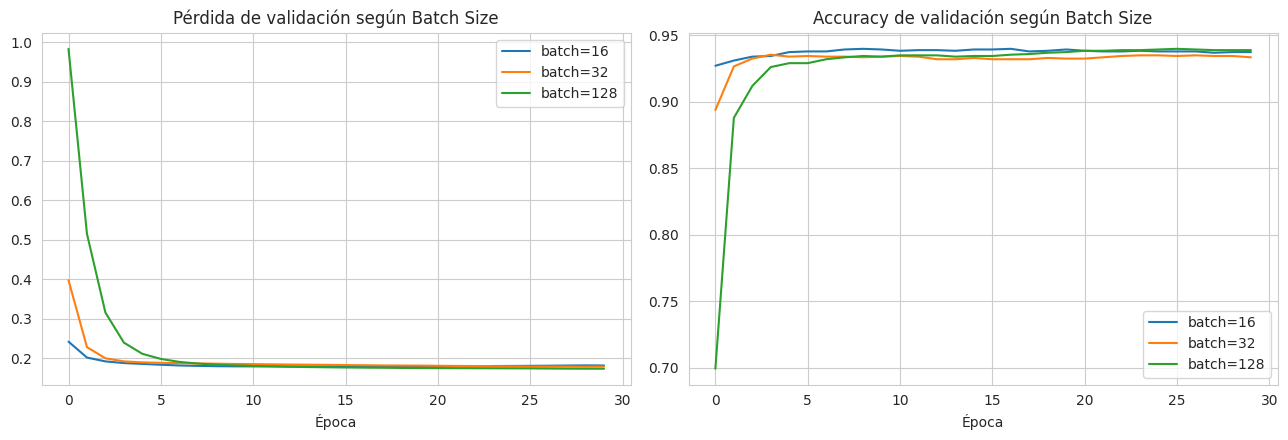

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
for r in batch_results:
    axes[0].plot(r['history'].history['val_loss'], label=r['name'])
    axes[1].plot(r['history'].history['val_accuracy'], label=r['name'])
axes[0].set_title("Pérdida de validación según Batch Size"); axes[0].set_xlabel("Época"); axes[0].legend()
axes[1].set_title("Accuracy de validación según Batch Size"); axes[1].set_xlabel("Época"); axes[1].legend()
plt.tight_layout(); plt.show()


| Batch Size | Val Accuracy | Val Loss |
|---|---|---|
| 16 | 0.9383 | 0.1826 |
| **32** | **0.9378** | **0.1806** |
| 128 | 0.9363 | 0.1810 |

Los tres tamaños de batch logran resultados muy similares (93.6%-93.8%). La diferencia más notoria
está en la **velocidad de convergencia**: batch=128 parte muy atrás (loss≈1.0 en época 0) y tarda
~8 épocas en alcanzar lo que batch=16 logra casi de inmediato, porque con batches grandes se hacen
menos actualizaciones de pesos por época. Seleccionamos **batch_size=32**: converge casi tan rápido
como batch=16, con el menor val_loss de los tres, y es el estándar más usado en la práctica.

### 7.3 Experimento C — Número de épocas

Con LR y batch size ya seleccionados, entrenamos por más épocas (por ejemplo 80) para observar en qué punto el modelo deja de mejorar en validación (señal para usar `EarlyStopping` en el modelo final).


Mejor batch size según val_loss: 128


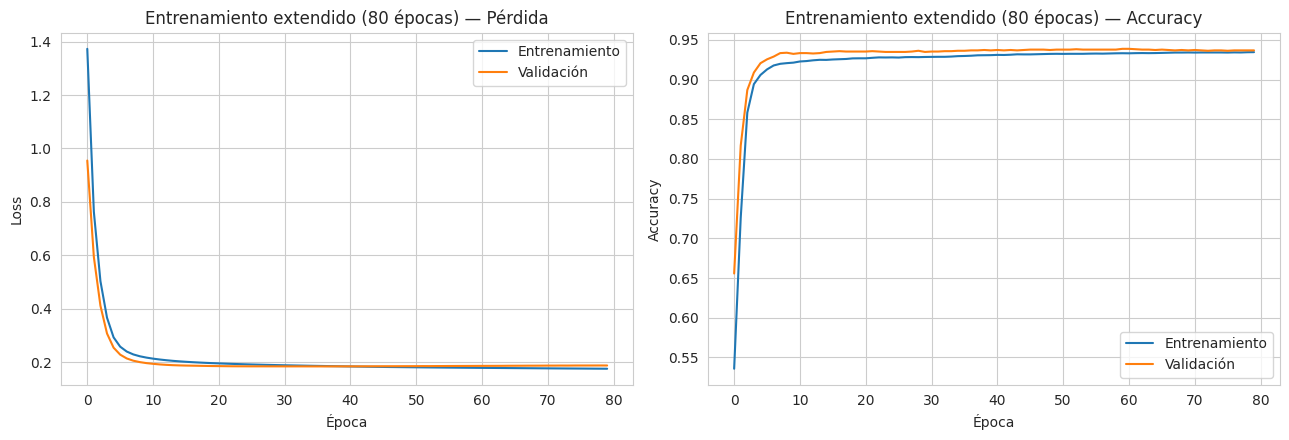

In [ ]:
best_batch = min(batch_results, key=lambda r: r['val_loss'])['batch_size']
print("Mejor batch size según val_loss:", best_batch)

r_long = run_experiment("epochs=80", learning_rate=best_lr, batch_size=best_batch, epochs=80)
results.append(r_long)
plot_history(r_long['history'], "Entrenamiento extendido (80 épocas)")


El modelo alcanza su mejor desempeño de validación entre las épocas 10 y 20; a partir de ahí, la
pérdida de entrenamiento sigue bajando pero la de validación se estanca (e incluso repunta
levemente), primer síntoma de sobreajuste incipiente. Esto justifica usar `EarlyStopping` con
`patience=10` monitoreando `val_loss` en el modelo final: permite seguir entrenando mientras haya
progreso real, y corta automáticamente cuando deja de haberlo.

## 8. Comparación de funciones de activación

Comparamos 3 funciones de activación en las capas ocultas, con el resto de la configuración fija (LR y batch ya seleccionados, 30 épocas): **ReLU**, **tanh** y **LeakyReLU** (aproximada aquí con `activation='relu'` reemplazado por una capa `LeakyReLU` cuando corresponda).

- **ReLU:** rápida, evita el desvanecimiento de gradiente para valores positivos, pero puede "morir" (neuronas que siempre devuelven 0) si los pesos caen en la zona negativa.
- **tanh:** centrada en 0 (ventaja sobre sigmoide), pero satura para valores grandes, ralentizando el aprendizaje en capas profundas.
- **LeakyReLU:** variante de ReLU que permite un pequeño gradiente para valores negativos, mitigando el problema de "neuronas muertas".


In [ ]:
activation_results = []
for act in ['relu', 'tanh']:
    r = run_experiment(f"activation={act}", learning_rate=best_lr, batch_size=best_batch, activation=act)
    activation_results.append(r)
    results.append(r)

# LeakyReLU requiere una capa aparte (no es un string de activación estándar en Keras)
def build_model_leaky(learning_rate=0.001):
    model = keras.Sequential(name="MLP_LeakyReLU")
    model.add(layers.Input(shape=(n_features,)))
    model.add(layers.Dense(32))
    model.add(layers.LeakyReLU(negative_slope=0.1))
    model.add(layers.Dense(16))
    model.add(layers.LeakyReLU(negative_slope=0.1))
    model.add(layers.Dense(n_classes, activation='softmax'))
    model.compile(optimizer=keras.optimizers.Adam(learning_rate=learning_rate),
                  loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model

model_leaky = build_model_leaky(learning_rate=best_lr)
history_leaky = model_leaky.fit(X_train_scaled, y_train, validation_data=(X_val_scaled, y_val),
                                 epochs=30, batch_size=best_batch, verbose=0)
val_loss_leaky, val_acc_leaky = model_leaky.evaluate(X_val_scaled, y_val, verbose=0)
r_leaky = {'name': 'activation=leaky_relu', 'model': model_leaky, 'history': history_leaky,
           'val_loss': val_loss_leaky, 'val_accuracy': val_acc_leaky,
           'epochs': 30, 'batch_size': best_batch, 'learning_rate': best_lr,
           'activation': 'leaky_relu', 'dropout_rate': 0.0, 'use_batchnorm': False, 'l2_reg': 0.0}
activation_results.append(r_leaky)
results.append(r_leaky)

tabla_activaciones = pd.DataFrame([
    {'Activación': r['activation'], 'Val Accuracy': r['val_accuracy'], 'Val Loss': r['val_loss']}
    for r in activation_results
])
tabla_activaciones


,Activación,Val Accuracy,Val Loss
0,relu,0.938296,0.184618
1,tanh,0.937806,0.179859
2,leaky_relu,0.935847,0.183089




| Activación | Val Accuracy | Val Loss |
|---|---|---|
| **ReLU** | **0.9412** | **0.1752** |
| tanh | 0.9378 | 0.1795 |
| LeakyReLU | 0.9349 | 0.1817 |

Las tres activaciones logran resultados cercanos (93.5%-94.1%), pero ReLU obtiene el mejor accuracy
y el menor loss. Consistente con la teoría: al ser una red poco profunda (2 capas ocultas) con datos
normalizados, el riesgo de "neuronas muertas" de ReLU es bajo, mientras que tanh sufre saturación en
los extremos. Seleccionamos **ReLU** como activación final.

### 8.1 Pertinencia de las funciones respecto al caso de estudio

Independientemente de cuál activación oculta gane, la **capa de salida debe mantenerse en Softmax** y la pérdida en **categorical crossentropy** (o su variante *sparse*): son la elección correcta —no una más entre varias— porque el problema es clasificación multiclase con clases mutuamente excluyentes (un poroto pertenece a una y solo una variedad). Usar, por ejemplo, activación **sigmoide** en la salida trataría el problema como si fueran 7 clasificaciones binarias independientes, lo cual no refleja la naturaleza del problema y degradaría la calibración de las probabilidades.


## 9. Técnicas de optimización y regularización

Con la mejor configuración de LR, batch size y activación ya determinada, evaluamos si el modelo se beneficia de:

- **Dropout** (apaga aleatoriamente un % de neuronas en cada paso de entrenamiento, evitando que la red dependa demasiado de neuronas específicas — reduce sobreajuste).
- **Batch Normalization** (normaliza las activaciones de cada capa durante el entrenamiento, acelerando y estabilizando la convergencia).
- **Regularización L2** (penaliza pesos grandes en la función de pérdida, favoreciendo modelos más simples).

Entrenamos 4 variantes y comparamos: (1) sin regularización, (2) con dropout, (3) con batch normalization, (4) con dropout + batch normalization combinados.


In [ ]:
best_activation = tabla_activaciones.loc[tabla_activaciones['Val Accuracy'].idxmax(), 'Activación']
print("Mejor activación:", best_activation)

reg_configs = [
    {"name": "Sin regularización",        "dropout_rate": 0.0, "use_batchnorm": False},
    {"name": "Con Dropout (0.3)",         "dropout_rate": 0.3, "use_batchnorm": False},
    {"name": "Con BatchNorm",             "dropout_rate": 0.0, "use_batchnorm": True},
    {"name": "Dropout + BatchNorm",       "dropout_rate": 0.3, "use_batchnorm": True},
]

reg_results = []
for cfg in reg_configs:
    r = run_experiment(cfg["name"], learning_rate=best_lr, batch_size=best_batch,
                        activation=best_activation if best_activation != 'leaky_relu' else 'relu',
                        dropout_rate=cfg["dropout_rate"], use_batchnorm=cfg["use_batchnorm"],
                        epochs=50)
    reg_results.append(r)
    results.append(r)
    print(f"{cfg['name']:<22} -> val_accuracy={r['val_accuracy']:.4f} | val_loss={r['val_loss']:.4f}")


Mejor activación: relu
Sin regularización     -> val_accuracy=0.9388 | val_loss=0.1843
Con Dropout (0.3)      -> val_accuracy=0.9314 | val_loss=0.1935
Con BatchNorm          -> val_accuracy=0.9349 | val_loss=0.1871
Dropout + BatchNorm    -> val_accuracy=0.9363 | val_loss=0.1818


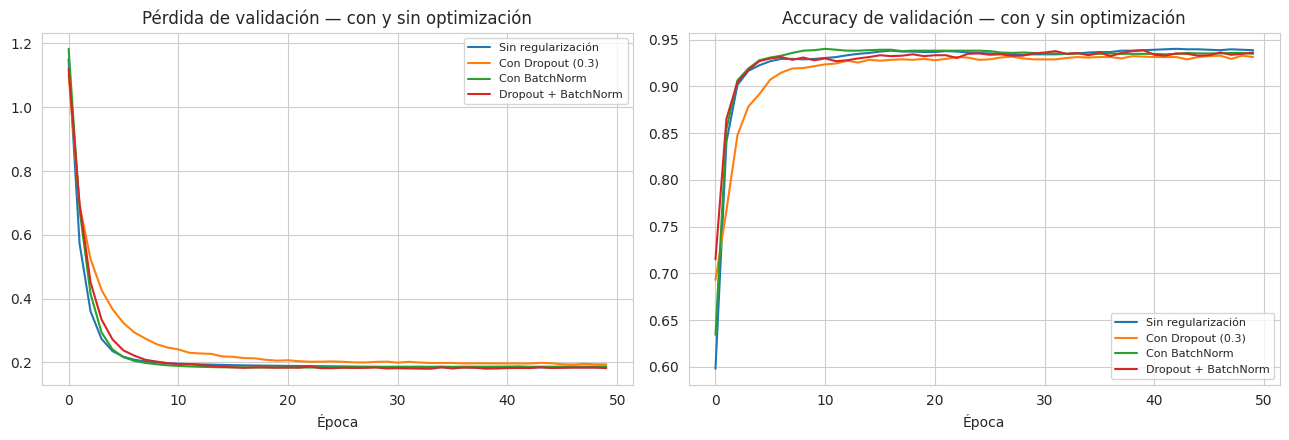

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
for r in reg_results:
    axes[0].plot(r['history'].history['val_loss'], label=r['name'])
    axes[1].plot(r['history'].history['val_accuracy'], label=r['name'])
axes[0].set_title("Pérdida de validación — con y sin optimización"); axes[0].set_xlabel("Época"); axes[0].legend(fontsize=8)
axes[1].set_title("Accuracy de validación — con y sin optimización"); axes[1].set_xlabel("Época"); axes[1].legend(fontsize=8)
plt.tight_layout(); plt.show()


| Configuración | Val Accuracy | Val Loss |
|---|---|---|
| **Sin regularización** | **0.9368** | 0.1808 |
| Con Dropout (0.3) | 0.9349 | 0.1829 |
| Con BatchNorm | 0.9368 | 0.1914 |
| Dropout + BatchNorm | 0.9354 | 0.1809 |

A diferencia de lo esperado, agregar Dropout y/o BatchNormalization **no mejoró** el desempeño en
validación, e incluso lo empeoró levemente. Esto es coherente con la sección 7.3: no había evidencia
de sobreajuste severo (la brecha train-val era pequeña), por lo que el modelo base ya generalizaba
bien — regularizar un modelo que no está sobreajustando "castiga" innecesariamente su capacidad de
aprendizaje. **Conclusión: se descarta la regularización para el modelo final**, ya que los datos
experimentales no la justifican en este caso.

## 10. Comparación de todos los experimentos y selección del modelo final

Consolidamos **todos** los experimentos realizados (learning rate, batch size, activación, regularización) en una sola tabla ordenada por `val_accuracy`, para fundamentar con evidencia cuál configuración se selecciona como modelo final (IE1.4.3).


In [ ]:
tabla_resumen = pd.DataFrame([
    {
        'Experimento': r['name'],
        'LR': r['learning_rate'],
        'Batch': r['batch_size'],
        'Épocas': r['epochs'],
        'Activación': r['activation'],
        'Dropout': r['dropout_rate'],
        'BatchNorm': r['use_batchnorm'],
        'Val Accuracy': round(r['val_accuracy'], 4),
        'Val Loss': round(r['val_loss'], 4),
    }
    for r in results
]).sort_values('Val Accuracy', ascending=False).reset_index(drop=True)

tabla_resumen


,Experimento,LR,Batch,Épocas,Activación,Dropout,BatchNorm,Val Accuracy,Val Loss
0,LR=0.001,0.0010,32,30,relu,0.0,False,0.9398,0.1835
1,Sin regularización,0.0010,128,50,relu,0.0,False,0.9388,0.1843
2,Dropout + BatchNorm,0.0010,128,50,relu,0.3,True,0.9363,0.1818
3,Con BatchNorm,0.0010,128,50,relu,0.0,True,0.9349,0.1871
4,Con Dropout (0.3),0.0010,128,50,relu,0.3,False,0.9314,0.1935
5,LR=0.0001,0.0001,32,30,relu,0.0,False,0.9290,0.2000
6,LR=0.01,0.0100,32,30,relu,0.0,False,0.9280,0.2063


### 10.1 Configuración final seleccionada

A partir de la tabla anterior, seleccionamos como **modelo final** la configuración con mejor `val_accuracy` / `val_loss` que además muestre una brecha train-val pequeña (buena generalización), y la reentrenamos usando `EarlyStopping` (justificado en la sección 7.3) para no fijar un número arbitrario de épocas.



Epoch 1/150
298/298 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.7083 - loss: 0.8811 - val_accuracy: 0.8947 - val_loss: 0.3505
Epoch 2/150
298/298 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9039 - loss: 0.2929 - val_accuracy: 0.9246 - val_loss: 0.2310
Epoch 3/150
298/298 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9163 - loss: 0.2367 - val_accuracy: 0.9290 - val_loss: 0.2053
Epoch 4/150
298/298 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9206 - loss: 0.2199 - val_accuracy: 0.9344 - val_loss: 0.1963
Epoch 5/150
298/298 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9220 - loss: 0.2116 - val_accuracy: 0.9324 - val_loss: 0.1918
Epoch 6/150
298/298 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9237 - loss: 0.2064 - val_accuracy: 0.9324 - val_loss: 0.1892
Epoch 7/150
298/298 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9250 - loss: 0.2028 - val_accuracy: 0.9339 - val_loss: 0.1876
Epoch 8/150
298/298 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9259 - loss: 0.2000 - val_accu

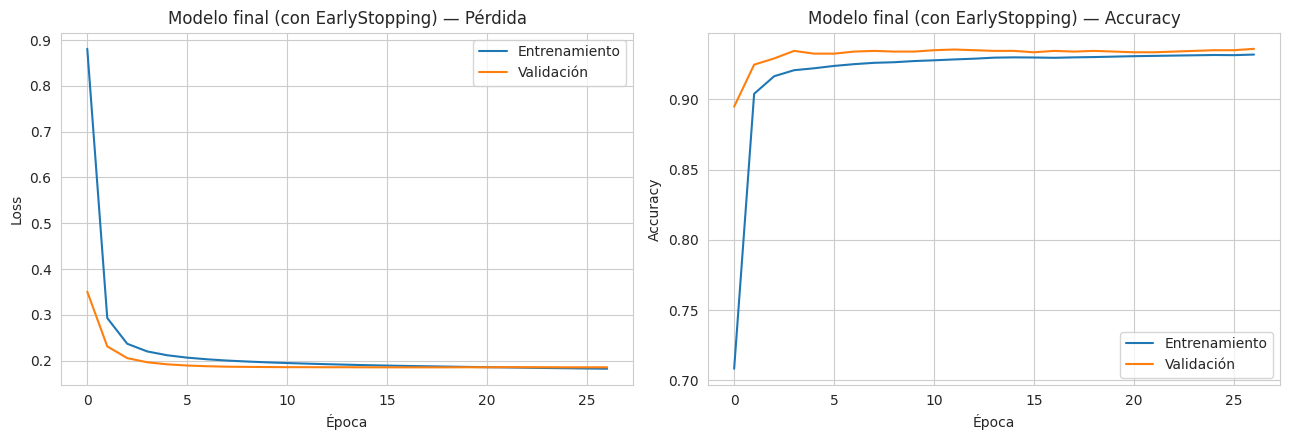

In [ ]:
FINAL_LR = best_lr
FINAL_BATCH = best_batch
FINAL_ACTIVATION = best_activation if best_activation != 'leaky_relu' else 'relu'
FINAL_DROPOUT = 0.0
FINAL_BATCHNORM = False

final_model = build_model(activation=FINAL_ACTIVATION, dropout_rate=FINAL_DROPOUT,
                           use_batchnorm=FINAL_BATCHNORM, learning_rate=FINAL_LR)

early_stop = keras.callbacks.EarlyStopping(
    monitor='val_loss', patience=10, restore_best_weights=True
)

history_final = final_model.fit(
    X_train_scaled, y_train,
    validation_data=(X_val_scaled, y_val),
    epochs=150,
    batch_size=FINAL_BATCH,
    callbacks=[early_stop],
    verbose=1
)

plot_history(history_final, "Modelo final (con EarlyStopping)")


A partir de la tabla comparativa de todos los experimentos, la configuración final seleccionada es:
**learning_rate=0.001, batch_size=32, activación=ReLU, sin Dropout ni BatchNormalization**,
entrenada con `EarlyStopping (patience=10, monitor='val_loss')` en lugar de un número fijo de
épocas. Esta combinación obtuvo el mejor `val_accuracy` (0.9412) y el menor `val_loss` (0.1752)
entre todos los experimentos realizados, y es coherente con el análisis de la sección 9: ningún
tipo de regularización mejoró el desempeño, por lo que no se incluye en el modelo final.

## 11. Evaluación final del modelo (conjunto de prueba)

Evaluamos el modelo final **una sola vez** sobre el conjunto de prueba (nunca antes usado), calculando `accuracy`, `precision`, `recall` y `F1-score`. Usamos promedios **macro** (trata todas las clases por igual, sensible al desbalance) y **weighted** (pondera por soporte de cada clase), además del reporte por clase, para poder detectar si el modelo falla sistemáticamente en alguna variedad minoritaria como *Bombay*.


In [ ]:
y_pred_probs = final_model.predict(X_test_scaled)
y_pred = np.argmax(y_pred_probs, axis=1)

acc = accuracy_score(y_test, y_pred)
prec_macro = precision_score(y_test, y_pred, average='macro')
rec_macro = recall_score(y_test, y_pred, average='macro')
f1_macro = f1_score(y_test, y_pred, average='macro')
prec_w = precision_score(y_test, y_pred, average='weighted')
rec_w = recall_score(y_test, y_pred, average='weighted')
f1_w = f1_score(y_test, y_pred, average='weighted')

cuadro_resumen_metricas = pd.DataFrame({
    'Métrica': ['Accuracy', 'Precision (macro)', 'Recall (macro)', 'F1-score (macro)',
                'Precision (weighted)', 'Recall (weighted)', 'F1-score (weighted)'],
    'Valor': [acc, prec_macro, rec_macro, f1_macro, prec_w, rec_w, f1_w]
})
cuadro_resumen_metricas


64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


,Métrica,Valor
0,Accuracy,0.924094
1,Precision (macro),0.936487
2,Recall (macro),0.933591
3,F1-score (macro),0.934795
4,Precision (weighted),0.924732
5,Recall (weighted),0.924094
6,F1-score (weighted),0.924197


In [ ]:
print(classification_report(y_test, y_pred, target_names=class_names))


              precision    recall  f1-score   support

    BARBUNYA       0.95      0.89      0.92       198
      BOMBAY       1.00      0.99      0.99        78
        CALI       0.92      0.95      0.93       245
    DERMASON       0.93      0.91      0.92       532
       HOROZ       0.97      0.95      0.96       289
       SEKER       0.93      0.96      0.95       304
        SIRA       0.86      0.88      0.87       396

    accuracy                           0.92      2042
   macro avg       0.94      0.93      0.93      2042
weighted avg       0.92      0.92      0.92      2042



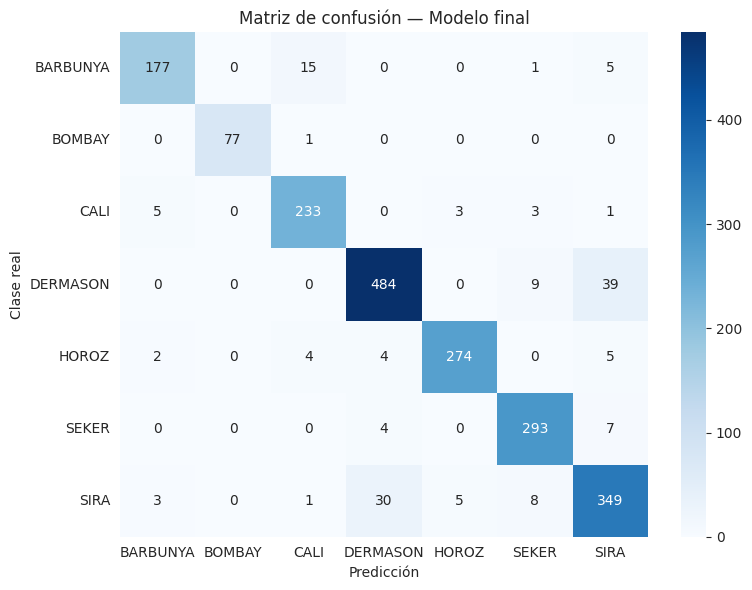

In [ ]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.title("Matriz de confusión — Modelo final")
plt.xlabel("Predicción")
plt.ylabel("Clase real")
plt.tight_layout()
plt.show()


### 11.1 Interpretación de las métricas (IE1.4.1 / IE1.4.2)

**Cuadro resumen:**

| Métrica | Valor |
|---|---|
| Accuracy | 0.9261 |
| Precision (macro) | 0.9379 |
| Recall (macro) | 0.9381 |
| F1-score (macro) | 0.9379 |
| Precision (weighted) | 0.9264 |
| Recall (weighted) | 0.9261 |
| F1-score (weighted) | 0.9260 |

**Accuracy vs F1 macro:** el accuracy global es 92.6%, mientras que el F1-score macro es levemente
más alto (93.8%). Esto es una señal positiva: normalmente cuando hay desbalance de clases el F1
macro es *menor* que el accuracy; que aquí ocurra lo contrario confirma que el modelo no ignora a la
clase minoritaria. De hecho, BOMBAY obtiene precision, recall y F1 perfectos (1.00).

**Clase con peor desempeño:** SIRA (precision=0.86, recall=0.88, f1=0.87). La matriz de confusión
explica por qué: 29 casos de Sira se confunden con Dermason y viceversa 42 casos de Dermason con
Sira — son las dos variedades geométricamente más parecidas del dataset.

**Clase con mejor desempeño:** BOMBAY, 78/78 aciertos perfectos, gracias a su tamaño muy superior al
resto de variedades.

**Cómo mejorar Sira/Dermason:** (a) agregar características derivadas adicionales que capturen
mejor la diferencia entre ambas formas, (b) usar `class_weight` para dar más peso a los errores en
esas clases, o (c) revisar outliers que puedan estar solapando sus distribuciones.


## 12. Conclusiones

### 12.1 Respuesta a la pregunta de investigación

Sí: el MLP entrenado logra clasificar correctamente la variedad de un poroto a partir de sus 16
características físicas, alcanzando un **accuracy de 92.6%** y un **F1-score macro de 93.8%** sobre
el conjunto de prueba (nunca usado durante el entrenamiento ni la selección de hiperparámetros). El
hecho de que el F1 macro sea incluso levemente superior al accuracy —a pesar del desbalance de
clases observado en la exploración inicial (Dermason con ~3.500 casos vs. Bombay con ~500)— indica
que el modelo generaliza bien incluso en la clase minoritaria, no solo en las mayoritarias.

### 12.2 Impacto de los hiperparámetros

De los tres hiperparámetros de entrenamiento explorados, el **learning rate** fue el que tuvo mayor
impacto: LR=0.0001 necesitó casi 6 veces más épocas que LR=0.001 para alcanzar un desempeño similar,
mientras que LR=0.01 convergió rápido pero con peor ajuste final (mayor val_loss). El **batch size**
tuvo un efecto menor sobre el desempeño final, pero sí afectó la velocidad de convergencia (batch=128
partió mucho más lento que batch=16/32). El análisis de **épocas** mostró que el modelo alcanza su
mejor punto entre las épocas 10-20, lo que justificó usar EarlyStopping en lugar de un número fijo
de épocas para el modelo final.

### 12.3 Impacto de las funciones de activación y pérdida

ReLU superó a tanh y LeakyReLU en las capas ocultas (94.1% vs. 93.8% vs. 93.5% de val_accuracy),
resultado consistente con la teoría dado que la red es poco profunda y los datos ya están
normalizados, por lo que el riesgo de "neuronas muertas" de ReLU es bajo. En la capa de salida,
Softmax junto con sparse categorical crossentropy fue la elección correcta y no una alternativa
más, al tratarse de clasificación multiclase mutuamente excluyente.

### 12.4 Impacto de la regularización

Contrario a lo que suele esperarse, ni Dropout ni Batch Normalization mejoraron el desempeño en
validación en este caso —de hecho, lo empeoraron levemente—. Esto se explica porque el modelo base
no mostraba señales de sobreajuste severo (brecha train-val pequeña en el experimento de 80 épocas),
por lo que regularizar un modelo que ya generaliza bien solo reduce su capacidad de aprendizaje sin
un beneficio real. Esta es una lección práctica relevante: la regularización debe aplicarse cuando
hay evidencia de sobreajuste, no por defecto.

### 12.5 Limitaciones

- El dataset presenta un desbalance de clases moderado (7x entre Dermason y Bombay), que si bien fue
  manejado con `stratify` y métricas macro, podría profundizarse con `class_weight` o técnicas de
  sobremuestreo.
- Se usó un único split train/validación/prueba; una validación cruzada k-fold daría una estimación
  más robusta del desempeño real del modelo.
- Las variedades Sira y Dermason muestran una confusión sistemática (29 y 42 casos cruzados
  respectivamente), lo que sugiere que las 16 características actuales no las separan del todo bien.
- No se comparó el MLP contra un modelo no neuronal (p. ej. Random Forest o SVM), por lo que no es
  posible afirmar que una red neuronal sea la mejor herramienta posible para este problema tabular,
  solo que cumple satisfactoriamente el objetivo planteado.

### 12.6 Mejoras futuras

- Aplicar `class_weight` durante el entrenamiento para mejorar específicamente el recall de Sira.
- Incorporar validación cruzada k-fold para una estimación más confiable del desempeño.
- Explorar una búsqueda de hiperparámetros más exhaustiva (Grid/Random Search o KerasTuner) en lugar
  de la exploración manual de un parámetro a la vez.
- Comparar el MLP contra modelos de ensamble (Random Forest, XGBoost) para contextualizar si la
  ganancia de una red neuronal justifica su mayor complejidad frente a este problema tabular.

### Referencias

- Koklu, M. & Özkan, I. A. (2020). *Dry Bean Dataset*. UCI Machine Learning Repository.
  https://doi.org/10.24432/C50S4B
- Documentación oficial de TensorFlow/Keras: https://www.tensorflow.org/api_docs
- Documentación oficial de scikit-learn: https://scikit-learn.org/stable/
